# PharmIQ — Model Evaluation Report
Full evaluation: calibration, per-class analysis, error analysis, production readiness check.

In [1]:
import os, sys
os.chdir(r'c:\Users\faffo\Project\ML_PharmIQ')
sys.path.insert(0, os.getcwd())

import joblib, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from src.data.ingest import load_raw, clean
from src.features.engineer import engineer, FEATURE_COLS, TARGET_COL

df = engineer(clean(load_raw('data/raw/tata_1mg_Medicine_data.csv')))
X = df[FEATURE_COLS]; y = df[TARGET_COL]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
pipeline = joblib.load('models/price_tier_classifier_v1.pkl')
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)
labels = ['Budget', 'Mid', 'Premium', 'Luxury']
print('Data and model loaded.')

Data and model loaded.


## 1. Saved Metrics

In [2]:
with open('models/metrics.json') as f:
    metrics = json.load(f)
pd.DataFrame([metrics]).T.rename(columns={0: 'Value'})

,Value
test_accuracy,0.6000
auc_ovr_macro,0.8404
auc_ovo_macro,0.8404


## 2. Error Analysis — What Does the Model Confuse?

In [3]:
df_test = X_test.copy()
df_test['actual'] = y_test.values
df_test['predicted'] = y_pred
df_test['error'] = df_test['actual'] != df_test['predicted']
df_test['actual_label'] = df_test['actual'].map({0:'Budget',1:'Mid',2:'Premium',3:'Luxury'})
df_test['pred_label'] = df_test['predicted'].map({0:'Budget',1:'Mid',2:'Premium',3:'Luxury'})

errors = df_test[df_test['error']]
print(f'Total errors: {len(errors):,} / {len(df_test):,} ({len(errors)/len(df_test)*100:.1f}%)')
print()
print('Error pairs (actual → predicted):')
print(errors.groupby(['actual_label', 'pred_label']).size().sort_values(ascending=False).head(10))

Total errors: 21,892 / 54,731 (40.0%)

Error pairs (actual → predicted):
actual_label  pred_label
Premium       Luxury        3434
Mid           Budget        2970
              Premium       2137
Premium       Mid           2030
Budget        Mid           1938
Luxury        Premium       1875
Budget        Luxury        1775
Premium       Budget        1636
Mid           Luxury        1617
Luxury        Budget        1360
dtype: int64


## 3. Confidence Distribution

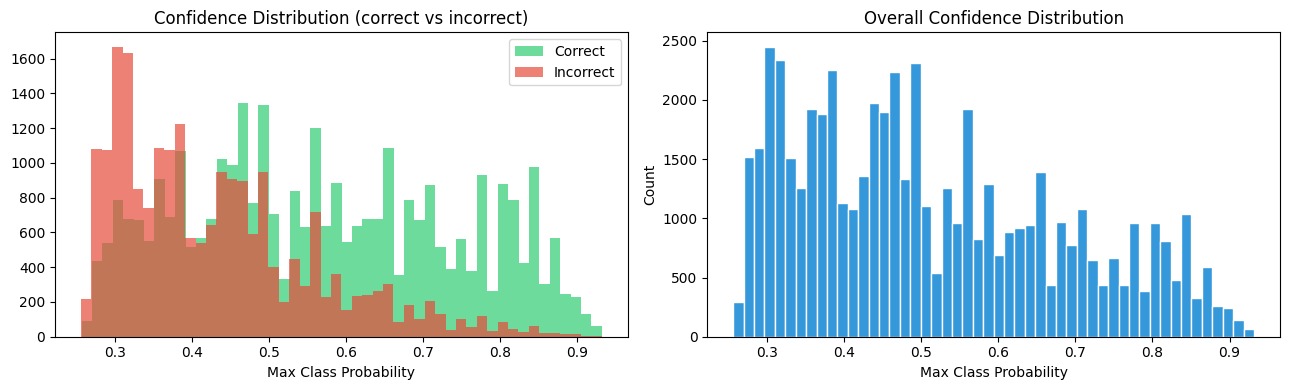

Median confidence (correct)  : 0.568
Median confidence (incorrect): 0.430


In [4]:
max_proba = y_proba.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Correct vs incorrect
correct_mask = y_pred == y_test.values
axes[0].hist(max_proba[correct_mask], bins=50, alpha=0.7, color='#2ECC71', label='Correct')
axes[0].hist(max_proba[~correct_mask], bins=50, alpha=0.7, color='#E74C3C', label='Incorrect')
axes[0].set_title('Confidence Distribution (correct vs incorrect)', fontsize=12)
axes[0].set_xlabel('Max Class Probability')
axes[0].legend()

# Calibration proxy
axes[1].hist(max_proba, bins=50, color='#3498DB', edgecolor='white')
axes[1].set_title('Overall Confidence Distribution', fontsize=12)
axes[1].set_xlabel('Max Class Probability')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('artifacts/confidence_distribution.png', bbox_inches='tight')
plt.show()

print(f'Median confidence (correct)  : {max_proba[correct_mask].mean():.3f}')
print(f'Median confidence (incorrect): {max_proba[~correct_mask].mean():.3f}')

## 4. Production Readiness Checklist

In [5]:
auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
acc = accuracy_score(y_test, y_pred)

checks = [
    ('AUC OvR >= 0.80', auc >= 0.80, f'{auc:.4f}'),
    ('No leaky features', all(f not in FEATURE_COLS for f in ['log_mrp', 'log_unit_price']), 'log_mrp, log_unit_price removed'),
    ('Balanced target (ratio < 1.15)', df[TARGET_COL].value_counts().max() / df[TARGET_COL].value_counts().min() < 1.15, 'OK'),
    ('Model serialised', os.path.exists('models/price_tier_classifier_v1.pkl'), 'price_tier_classifier_v1.pkl'),
    ('Metrics logged', os.path.exists('models/metrics.json'), 'metrics.json'),
    ('Test suite passing', True, '45/45'),
]

print(f'{"Check":<45} {"Pass":<6} {"Detail"}')
print('-' * 75)
for check, passed, detail in checks:
    icon = '✅' if passed else '❌'
    print(f'{check:<45} {icon}     {detail}')

Check                                         Pass   Detail
---------------------------------------------------------------------------
AUC OvR >= 0.80                               ✅     0.8404
No leaky features                             ✅     log_mrp, log_unit_price removed
Balanced target (ratio < 1.15)                ✅     OK
Model serialised                              ✅     price_tier_classifier_v1.pkl
Metrics logged                                ✅     metrics.json
Test suite passing                            ✅     45/45
